### Import Dependecies

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler,
)

### 02. Import data

In [2]:
df = pd.read_csv("data/processed/feature_engineered.csv")
df.head()

,purchase_value,age,class,account_age_minutes,purchase_hour,purchase_day_of_week,is_weekend,is_night,device_txn_count_total,is_device_new,purchase_value_log,purchase_value_zscore,is_outlier_amount,browser_fraud_rate,source_fraud_rate,country_fraud_rate
0,14,38,1,0.016667,0,3,0,1,10,1,2.70805,-1.251742,0,0.099043,0.092762,0.087107
1,14,38,1,0.016667,0,3,0,1,10,0,2.70805,-1.251742,0,0.098396,0.091780,0.093508
2,14,38,1,0.016667,0,3,0,1,10,0,2.70805,-1.251742,0,0.099151,0.092440,0.092197
3,14,38,1,0.016667,0,3,0,1,10,0,2.70805,-1.251742,0,0.098614,0.091296,0.094155
4,14,38,1,0.016667,0,3,0,1,10,0,2.70805,-1.251742,0,0.099043,0.092762,0.087107


### 03 Data splting

In [4]:
target="class"
X = df.drop(columns=[target])
y = df[target]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

### 04 Preprocessing:  scaling

In [12]:
Scaling_columns = df.drop(columns=[target]).columns.to_list()

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), Scaling_columns),
    ],
    remainder="drop"
)

#### 4.1 FIT on TRAIN only

In [14]:
X_train_processed = preprocessor.fit_transform(X_train, y_train)

#### 4.2 TRANSFORM test (no fit)

In [15]:
X_test_processed = preprocessor.transform(X_test)

In [16]:
joblib.dump(preprocessor, "artifacts/preprocessor.joblib")

['artifacts/preprocessor.joblib']

In [19]:
X_train_processed = pd.DataFrame(
    X_train_processed,
    columns=Scaling_columns
)

In [22]:
X_test_processed = pd.DataFrame(
    X_test_processed,
    columns=Scaling_columns
)

### 5. Class Distribution Visualization

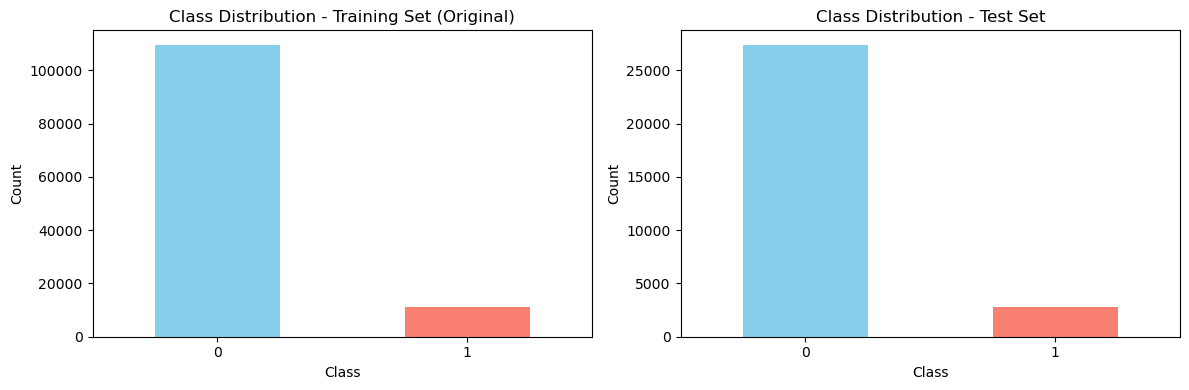


Training set class distribution:
class
0    109568
1     11321
Name: count, dtype: int64

Test set class distribution:
class
0    27393
1     2830
Name: count, dtype: int64


In [23]:
plt.figure(figsize=(12, 4))

# Training Set (original, unbalanced)
plt.subplot(121)
y_train.value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Class Distribution - Training Set (Original)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)

# Test Set
plt.subplot(122)
y_test.value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Class Distribution - Test Set')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"\nTest set class distribution:")
print(y_test.value_counts())

### 7. Saving Dataset

In [24]:
## saving trainin set
X_train_processed.to_csv("artifacts/X_train.csv",index=False)
y_train.to_csv("artifacts/y_train.csv",index=False)

## saving test set
X_test_processed.to_csv("artifacts/X_test.csv",index=False)
y_test.to_csv("artifacts/y_test.csv",index=False)